# 29 — Comparing the shipped regional maps

Three regional rock-abundance maps now exist over the same 26 Murray tiles of circum-Chryse:

| | where | what it is |
|---|---|---|
| **old** | `reports/map_region_g1` | the pre-R01 product, **archived** by PLAN_Rebuild step 12 |
| **new baseline** | `reports/map_region` | the promoted product: corrected lattice, corrected labels |
| **new A1** | `reports/map_a1` | the same, with the A1 per-source-frame CTX renormalisation. ⚠ **Demoted to a SENSITIVITY ARM on 2026-08-25 on the strength of §2 below** — it is not the product (§3) |

This notebook answers two questions Brian asked directly: **how different is the new map from the
old one, and how different is A1 from the baseline?**

They are not the same kind of question, and conflating them would be the main way to get this
wrong:

* **baseline vs A1 is an exact comparison.** Both arms were rendered on one lattice and
  `scripts/verify_arm_parity.py` confirms **26/26 cell-for-cell co-registration** with one
  size-floor basis. Their difference is a difference in *the thing being measured*.
* **old vs new is not a controlled comparison at all.** Three things changed at once — the R01
  re-anchoring (pure geometry), the R74+R29 label basis (rich prevalence 0.3598 → 0.373272), and
  a re-fit head and calibrator — and the artifacts **cannot separate them**. §1 says what can
  still be concluded, and bounds the geometry term rather than waving at it.

*(Companion notebooks: [24](24_regional_map.ipynb) is the regional-map home,
[25](25_striping_artifact.ipynb) diagnosed the source-frame artifact A1 was built to mitigate.)*


In [1]:
import json
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import rasterio
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from src import map_qa
from src.mapping import assert_coregistered

FIG = REPO / "reports" / "figures"
ARMS = {"old_g1": REPO / "reports" / "map_region_g1",
        "new_base": REPO / "reports" / "map_region",
        "new_a1": REPO / "reports" / "map_a1"}


def mosaic(arm, layer="abundance"):
    p = ARMS[arm] / f"regional_{layer}_mosaic.tif"
    with rasterio.open(p) as ds:
        a = ds.read(1).astype(np.float64)
        nd = ds.nodata
    if nd is not None and np.isfinite(nd):
        a[a == nd] = np.nan
    return a


def grid_of(arm, layer="abundance"):
    with rasterio.open(ARMS[arm] / f"regional_{layer}_mosaic.tif") as ds:
        return ds.transform, (ds.height, ds.width)


for arm, d in ARMS.items():
    n = len([p for p in d.glob("*_abundance.tif") if not p.name.startswith("regional_")])
    print(f"{arm:9s} {n} tiles  {d.relative_to(REPO)}")


old_g1    26 tiles  reports\map_region_g1
new_base  26 tiles  reports\map_region
new_a1    26 tiles  reports\map_a1


## §0 — What may be compared with what

Before any number: the two pairings have different standing. This cell states it from the
artifacts rather than from memory.


In [2]:
rows = []
for a in ("old_g1", "new_base", "new_a1"):
    tf, shape = grid_of(a)
    rows.append({"arm": a, "shape": f"{shape[0]}x{shape[1]}",
                 "origin_x": round(tf.c, 3), "origin_y": round(tf.f, 3),
                 "cell_m": round(tf.a, 6)})
print(pd.DataFrame(rows).to_string(index=False))

print()
for pair in (("new_base", "new_a1"), ("new_base", "old_g1")):
    ta, sa = grid_of(pair[0]); tb, sb = grid_of(pair[1])
    try:
        assert_coregistered(ta, tb, shape_a=sa, shape_b=sb)
        print(f"{pair[0]} vs {pair[1]:9s} -> CO-REGISTERED: compare cell-for-cell")
    except Exception as e:
        print(f"{pair[0]} vs {pair[1]:9s} -> NOT co-registered: "
              f"{str(e).split('--')[-1].strip().splitlines()[0]}")
        print(f"{'':28s}   must be compared by world coordinates or by distribution")


     arm      shape    origin_x    origin_y     cell_m
  old_g1 5925x11852 -711136.371 2845025.482 159.999184
new_base 5925x11852 -711036.372 2844945.482 159.999184
  new_a1 5925x11852 -711036.372 2844945.482 159.999184

new_base vs new_a1    -> CO-REGISTERED: compare cell-for-cell
new_base vs old_g1    -> NOT co-registered: offset (-100.0, +80.0) m.
                               must be compared by world coordinates or by distribution


In [3]:
# The per-tile sub-cell phase census -- the R01 defect itself, measured on both products.
def phases(arm):
    out = set()
    for p in sorted(ARMS[arm].glob("*_abundance.tif")):
        if p.name.startswith("regional_"):
            continue
        with rasterio.open(p) as ds:
            t = ds.transform
        out.add((round(t.c % t.a, 3), round(t.f % abs(t.e), 3)))
    return out


for arm in ARMS:
    ph = phases(arm)
    print(f"{arm:9s} {len(ph):2d} distinct sub-cell lattice phase(s)")
print()
print("`rasterio.merge` floors each tile's fractional destination offset, so a per-tile")
print("sub-cell phase becomes a WHOLE-CELL displacement in the mosaic. That is R01, and it")
print("is why the old product's 26 phases are not a cosmetic detail.")


old_g1    26 distinct sub-cell lattice phase(s)


new_base   4 distinct sub-cell lattice phase(s)


new_a1     4 distinct sub-cell lattice phase(s)

`rasterio.merge` floors each tile's fractional destination offset, so a per-tile
sub-cell phase becomes a WHOLE-CELL displacement in the mosaic. That is R01, and it
is why the old product's 26 phases are not a cosmetic detail.


In [4]:
# Provenance: what each product can say about itself.
KEYS = ["grid_id", "head", "head_digest", "calibration_digest", "rasters", "nodata_gate",
        "overlap", "run", "cell_row0", "n_unique_cells"]
rows = []
for arm in ARMS:
    sc = map_qa.load_arm(ARMS[arm])
    one = sc[sorted(sc)[0]]
    row = {"arm": arm, "n_keys": len(one)}
    row.update({k: ("yes" if one.get(k) not in (None, [], {}) else "--") for k in KEYS})
    with rasterio.open(next(p for p in ARMS[arm].glob("*_abundance.tif")
                           if not p.name.startswith("regional_"))) as ds:
        row["raster_tags"] = len(ds.tags())
    rows.append(row)
print(pd.DataFrame(rows).set_index("arm").T.to_string())


arm                old_g1 new_base new_a1
n_keys                 11       30     51
grid_id                --      yes    yes
head                   --      yes    yes
head_digest            --      yes    yes
calibration_digest     --      yes    yes
rasters                --      yes    yes
nodata_gate            --      yes    yes
overlap                --       --     --
run                    --      yes    yes
cell_row0              --      yes    yes
n_unique_cells         --      yes     --
raster_tags             1       13     13


**The archived product is not self-describing.** Its sidecars are a 10-key stub and its
rasters carry a single tag (`AREA_OR_POINT`): no `grid_id`, no head, no calibration digest, no
per-raster SHA-256, no nodata-gate accounting, no size-floor basis. So we cannot even *read off*
which head produced the old map — we know from `DECISIONS.md`, not from the artifact.

That is the first and most durable difference between the two generations, and it is the one that
would matter most if the old map were ever quoted again: **it cannot be audited.** Everything
below is about the numbers; this is about whether the numbers could be traced at all.


## §1 — Old vs new

### §1a The comparison is confounded by construction

Between the two products, all of these changed together:

1. **Geometry (R01).** Every tile was re-anchored to one global lattice
   (`murray_v01_clon0_R3396190_ppd11855_S32_anchor_lonlat0`). Mosaic origin moved
   **−100 m E / +80 m N**, and 25 of 26 tiles had additionally been displaced by the merge-floor
   effect, median 140 m.
2. **The label basis (R74 + R29).** Deep-shadow pixels are no longer called "no coverage", so the
   training pool went 161,005 → 164,644 tiles and **rich prevalence 0.3598 → 0.373272**.
3. **The model and the calibrator.** Both were re-fit on that basis.

No artifact on disk lets these be separated, and re-rendering to isolate one would cost ~23 GPU-h.
So the honest reading is: report the **net** difference, and **bound the part that is only placement**
— which needs no re-render at all.


In [5]:
# The geometry bound: displace the PROMOTED map against ITSELF by known offsets.
# Whatever difference that produces is what pure placement is worth on this field.
NEW_AB = ARMS["new_base"] / "regional_abundance_mosaic.tif"
bounds = {}
for dx, dy, why in ((-100.0, 80.0, "the archived mosaic's own origin offset"),
                    (-140.0, 0.0, "the median per-tile merge-floor displacement"),
                    (-160.0, 0.0, "one whole cell, for scale")):
    s = map_qa.displacement_sensitivity(NEW_AB, dx, dy)
    bounds[(dx, dy)] = s
    print(f"shift ({dx:+6.0f}, {dy:+5.0f}) m  [{why}]")
    print(f"    sd(Δ) {s['sd']:.6f}   p01 {s['p01']:+.6f}   p99 {s['p99']:+.6f}   "
          f"max|Δ| {s['max_abs']:.6f}")

# The REAL old-vs-new difference: warp the old mosaic onto the new grid (one resample, of the
# OLDER product only -- the shipped map is never resampled).
old_on_new = map_qa.raster_onto(ARMS["old_g1"] / "regional_abundance_mosaic.tif", NEW_AB)
new_ab = mosaic("new_base")
real = map_qa.difference_stats(old_on_new.astype(np.float64), new_ab)
print(f"\nREAL old->new difference   sd(Δ) {real['sd']:.6f}   p01 {real['p01']:+.6f}   "
      f"p99 {real['p99']:+.6f}   max|Δ| {real['max_abs']:.6f}")
print(f"    mean {real['mean']:+.6f}   median {real['median']:+.6f}   n {real['n_common']:,}")

g = bounds[(-140.0, 0.0)]["sd"]
print(f"\n=> sd(real) / sd(140 m shift) = {real['sd'] / g:.3f}")


shift (  -100,   +80) m  [the archived mosaic's own origin offset]
    sd(Δ) 0.003511   p01 -0.012464   p99 +0.010982   max|Δ| 0.071812


shift (  -140,    +0) m  [the median per-tile merge-floor displacement]
    sd(Δ) 0.004122   p01 -0.013868   p99 +0.013807   max|Δ| 0.087973


shift (  -160,    +0) m  [one whole cell, for scale]
    sd(Δ) 0.004712   p01 -0.015850   p99 +0.015781   max|Δ| 0.100540



REAL old->new difference   sd(Δ) 0.004375   p01 -0.014141   p99 +0.014762   max|Δ| 0.115730
    mean +0.000111   median +0.000000   n 56,750,279

=> sd(real) / sd(140 m shift) = 1.061


### §1b The result: at the pixel level, the old and new maps differ barely more than the same map shifted one cell

`sd(Δ)` for the real old→new change is **0.00438**. Displacing the *new* map by 140 m — the median
tile displacement the rebuild corrected — produces **0.00412** on its own, and a full one-cell
(160 m) shift produces **0.00471**.

So the real difference sits **between a 140 m and a 160 m displacement of the same field**: a ratio
of ≈1.06. **Almost all of the per-pixel old-vs-new difference is placement, not content.** The
median difference is exactly 0.

⚠ **This does not mean the two maps are interchangeable**, and §1c is why. A comparison that stopped
here would be as misleading as one that quoted the difference map alone.


In [6]:
# Distributions need no resampling and carry no co-registration caveat: two maps of the
# same region can be compared as POPULATIONS even when they are not comparable cell-for-cell.
dist = {}
for layer in ("prob_raw", "prob", "abundance"):
    arrs = {}
    for arm in ARMS:
        p = ARMS[arm] / f"regional_{layer}_mosaic.tif"
        if p.exists():
            arrs[arm] = mosaic(arm, layer)
    dist[layer] = map_qa.quantile_table(arrs)
    print(f"--- {layer}")
    for n, r in dist[layer].items():
        print(f"    {n:9s} mean {r['mean']:.6f}  sd {r['sd']:.6f}  "
              f"IQR {r['p25']:.6f}-{r['p75']:.6f}  p99 {r['p99']:.6f}  "
              f"max {r['p100']:.6f}  zero {r['zero_fraction']:.4f}")
print("\n(the archived product has no prob_raw mosaic -- that layer postdates it)")


--- prob_raw
    new_base  mean 0.205273  sd 0.246696  IQR 0.028480-0.288224  p99 0.958718  max 0.999807  zero 0.0000
    new_a1    mean 0.177984  sd 0.254823  IQR 0.011355-0.232374  p99 0.985590  max 0.999997  zero 0.0000


--- prob
    old_g1    mean 0.215260  sd 0.197538  IQR 0.086487-0.247899  p99 0.850317  max 1.000000  zero 0.0001
    new_base  mean 0.236605  sd 0.173885  IQR 0.136848-0.228104  p99 0.816000  max 0.995816  zero 0.0000
    new_a1    mean 0.218200  sd 0.177605  IQR 0.130905-0.184027  p99 0.900155  max 1.000000  zero 0.0000


--- abundance
    old_g1    mean 0.005004  sd 0.009789  IQR 0.000000-0.005469  p99 0.048889  max 0.293242  zero 0.3097
    new_base  mean 0.005113  sd 0.009000  IQR 0.000312-0.005781  p99 0.044985  max 0.151043  zero 0.2059
    new_a1    mean 0.004850  sd 0.011131  IQR 0.000000-0.004727  p99 0.057798  max 0.293242  zero 0.3516

(the archived product has no prob_raw mosaic -- that layer postdates it)


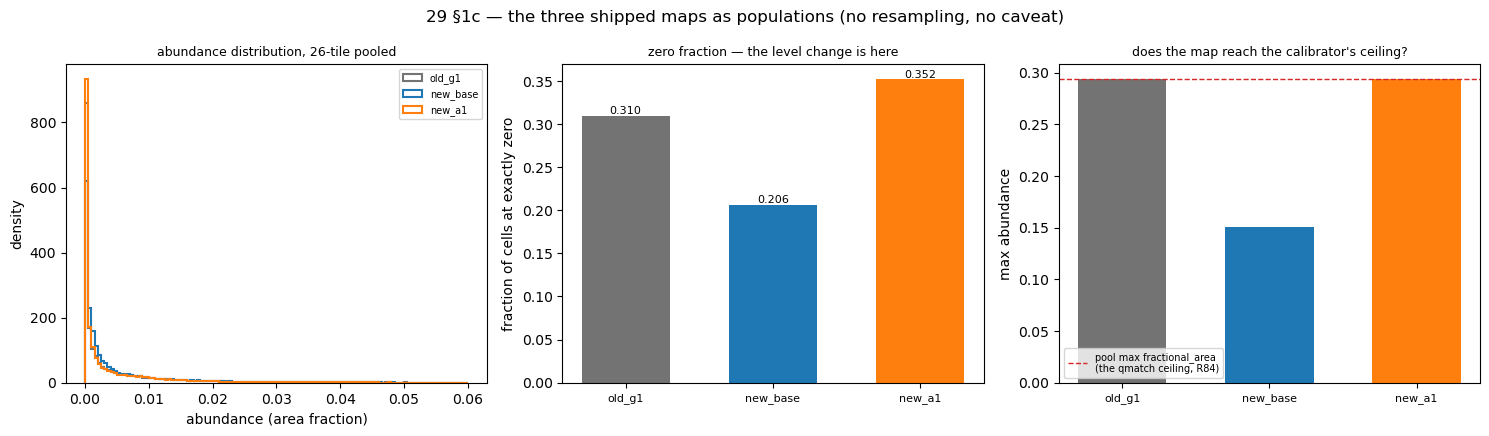

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

ab = {k: mosaic(k) for k in ("old_g1", "new_base", "new_a1")}
bins = np.linspace(0, 0.06, 121)
for k, c in (("old_g1", "0.45"), ("new_base", "tab:blue"), ("new_a1", "tab:orange")):
    v = ab[k][np.isfinite(ab[k])]
    ax[0].hist(v, bins=bins, histtype="step", lw=1.5, color=c, density=True, label=k)
ax[0].set_xlabel("abundance (area fraction)")
ax[0].set_ylabel("density")
ax[0].set_title("abundance distribution, 26-tile pooled", fontsize=9)
ax[0].legend(fontsize=7)

names = ["old_g1", "new_base", "new_a1"]
zf = [dist["abundance"][n]["zero_fraction"] for n in names]
mx = [dist["abundance"][n]["p100"] for n in names]
x = np.arange(3)
ax[1].bar(x, zf, 0.6, color=["0.45", "tab:blue", "tab:orange"])
ax[1].set_xticks(x, names, fontsize=8)
ax[1].set_ylabel("fraction of cells at exactly zero")
ax[1].set_title("zero fraction — the level change is here", fontsize=9)
for i, v in enumerate(zf):
    ax[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax[2].bar(x, mx, 0.6, color=["0.45", "tab:blue", "tab:orange"])
ax[2].axhline(0.293242, color="tab:red", ls="--", lw=1,
              label="pool max fractional_area\n(the qmatch ceiling, R84)")
ax[2].set_xticks(x, names, fontsize=8)
ax[2].set_ylabel("max abundance")
ax[2].set_title("does the map reach the calibrator's ceiling?", fontsize=9)
ax[2].legend(fontsize=7)
fig.suptitle("29 §1c — the three shipped maps as populations (no resampling, no caveat)")
fig.tight_layout()
fig.savefig(FIG / "29_oldnew_distributions.png", dpi=110)
plt.show()


### §1c ...but the *level* and the *dynamic range* did change

The distributions are **not** the same field, even though the per-pixel difference was mostly
placement:

* **the zero fraction fell 0.310 → 0.206** — a third fewer cells pinned at exactly zero, which is
  the direct expression of the corrected labels' higher rich prevalence;
* **the median rose 0.00090 → 0.00148** (+65 %);
* **the new baseline no longer reaches the calibrator's ceiling.** The old map's max is
  **0.293242**, exactly the pool max `fractional_area` that the Tier-2 quantile-match maps onto
  (R84's invariant). The new baseline tops out at **0.151** — it never assigns a cell the richest
  value the calibrator can express, over this whole region.

**So the two products differ in level, not in pattern.** The spatial arrangement of rich and poor
terrain is largely the same field, moved; what changed is how much abundance is assigned to it and
how much of the calibrated range is used. That is the correct one-sentence answer to "how different
is the new map from the old one?", and it is a different sentence from either half alone.


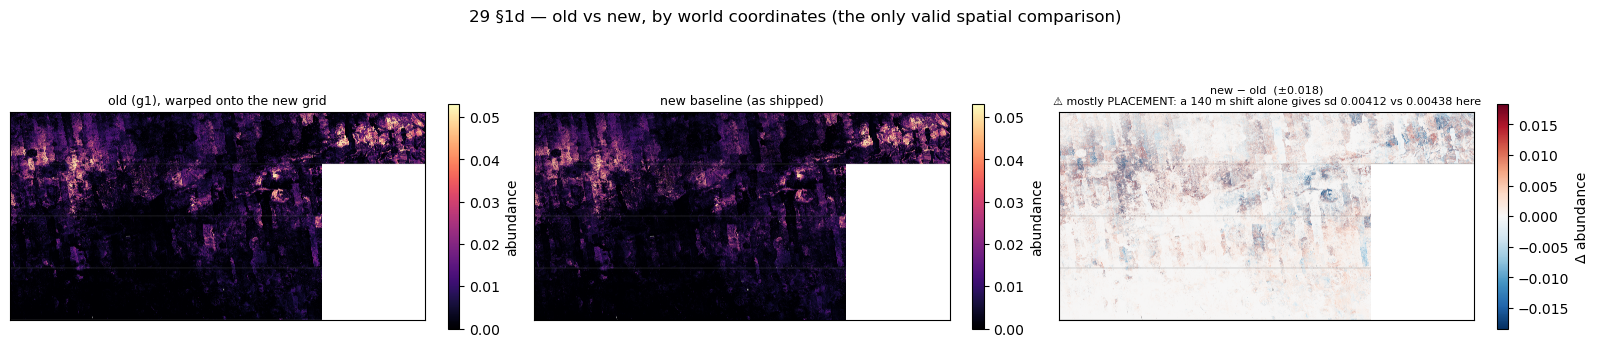

In [8]:
# Spatial view. The old product is the one resampled; the shipped map is shown as-is.
fig, ax = plt.subplots(1, 3, figsize=(16, 4.0))
vmax = float(np.nanpercentile(new_ab, 99.5))
for a, arr, t in ((ax[0], old_on_new, "old (g1), warped onto the new grid"),
                  (ax[1], new_ab, "new baseline (as shipped)")):
    im = a.imshow(arr, vmin=0, vmax=vmax, cmap="magma")
    a.set_title(t, fontsize=9)
    a.set_xticks([]); a.set_yticks([])
    plt.colorbar(im, ax=a, fraction=0.025, label="abundance")

d = new_ab - old_on_new
lim = float(np.nanpercentile(np.abs(d), 99))
im = ax[2].imshow(d, vmin=-lim, vmax=lim, cmap="RdBu_r")
ax[2].set_title(f"new − old  (±{lim:.3f})\n⚠ mostly PLACEMENT: a 140 m shift alone gives "
                f"sd {bounds[(-140.0, 0.0)]['sd']:.5f} vs {real['sd']:.5f} here", fontsize=8)
ax[2].set_xticks([]); ax[2].set_yticks([])
plt.colorbar(im, ax=ax[2], fraction=0.025, label="Δ abundance")
fig.suptitle("29 §1d — old vs new, by world coordinates (the only valid spatial comparison)")
fig.tight_layout()
fig.savefig(FIG / "29_oldnew_spatial.png", dpi=110)
plt.show()


In [9]:
# Don't read the difference map by eye -- test it. Two diagnostics separate "the same field,
# moved" from "a different field", with a SYNTHETIC pure shift as the calibration point.
import rasterio as _rio
from rasterio.transform import Affine
from src import validation_retrieve as vr

with _rio.open(NEW_AB) as ds:
    _tf, _crs, _shape = ds.transform, ds.crs.to_wkt(), (ds.height, ds.width)
_moved_tf = Affine(_tf.a, _tf.b, _tf.c - 140.0, _tf.d, _tf.e, _tf.f)
_synth = vr.reproject_to_grid(new_ab.astype(np.float32), _moved_tf, _crs, dst_crs_wkt=_crs,
                              dst_transform=_tf, dst_shape=_shape, resampling="bilinear")

a1_ab_pre = mosaic("new_a1")
char = {
    "SYNTHETIC pure 140 m shift": map_qa.difference_character(
        _synth.astype(np.float64) - new_ab, new_ab),
    "REAL old -> new": map_qa.difference_character(new_ab - old_on_new.astype(np.float64), new_ab),
    "A1 - baseline": map_qa.difference_character(a1_ab_pre - new_ab, new_ab),
}
print(pd.DataFrame(char).T[["gradient_rho", "top_decile_gradient_share",
                            "sd_total", "sd_smoothed", "smooth_variance_share"]]
      .round(4).to_string())
print("\ngradient_rho          : a pure translation errs where the field is steep -> scores high")
print("smooth_variance_share : variance surviving a ~9.6 km box filter -> a translation loses it,")
print("                        a genuine regional re-levelling keeps it")


                            gradient_rho  top_decile_gradient_share  sd_total  sd_smoothed  smooth_variance_share
SYNTHETIC pure 140 m shift        0.7881                     0.3745    0.0041       0.0001                 0.0003
REAL old -> new                   0.7639                     0.3348    0.0044       0.0010                 0.0488
A1 - baseline                     0.7184                     0.3176    0.0071       0.0041                 0.3372

gradient_rho          : a pure translation errs where the field is steep -> scores high
smooth_variance_share : variance surviving a ~9.6 km box filter -> a translation loses it,
                        a genuine regional re-levelling keeps it


### §1d Reading the difference map — tested, not eyeballed

| difference | ρ(\|Δ\|, \|∇field\|) | variance surviving 9.6 km smoothing |
|---|---|---|
| synthetic pure 140 m shift (calibration) | +0.788 | **0.0003** |
| **real old → new** | **+0.764** | **0.049** |
| A1 − baseline (for contrast) | +0.718 | **0.337** |

The real old→new difference has **essentially the same gradient affinity as a pure translation**
(0.764 vs 0.788), and **95 % of its variance is high-frequency**. Together with §1b's magnitude
bound, the dominant term in old → new is unambiguously **the same field, moved**.

But the regional share is **0.049, not the 0.0003 a pure shift gives** — about 160× more. That
residual is small in variance terms and it is *not* noise: it is precisely the level change §1c
measured on the distributions (zero fraction 0.310 → 0.206, median +65 %, ceiling no longer
reached). So the two sections agree, and together they give the full answer: **a small genuine
regional re-levelling sitting under a much larger displacement.**

The contrast row is the point of running the test at all. A1 − baseline is *also* gradient-
associated (any change concentrates near edges), but **33.7 % of its variance is regional** —
seven times old→new's share and a thousand times a pure shift's. The two comparisons in this
notebook are therefore qualitatively different kinds of change, and by eye the same difference map
would have looked much the same.

**Do not read the tile-edge structure in the §1d panel as an artifact of the new map.** It is the
old product's per-tile displacement, made visible by aligning it to the corrected lattice — a
picture of R01, not of a defect in what shipped.


## §2 — New baseline vs A1

This one is exact: same lattice, same cells, one size-floor basis, verified 26/26. Every number
below is a cell-for-cell comparison with no resampling anywhere.

**What A1 is.** The Fang embedder applies a fixed `/255` scaling, so each CTX source frame's own
radiometry propagates into the embedding and whole source frames read systematically rich or poor —
the rectangular-block artifact diagnosed in [notebook 25](25_striping_artifact.ipynb). A1
renormalises each source frame's DN (per-frame robust median/IQR, computed natively at 5 m/px:
`A1_ARM = a1_native_perframe_tilesupport_v2`) before embedding. §2c-§2e are whether that works.


In [10]:
base_ab, a1_ab = mosaic("new_base"), mosaic("new_a1")
diff = map_qa.difference_stats(base_ab, a1_ab)
print("A1 − baseline, abundance, cell-for-cell:")
for k in ("n_common", "only_a", "only_b", "mean", "sd", "median", "p01", "p99",
          "max_abs", "frac_nonzero"):
    print(f"    {k:13s} {diff[k]}")
print("\n`only_a`/`only_b` are both 0: identical footprints, so no cell is compared against")
print("a gap. That is what makes the difference below a difference in VALUE only.")


A1 − baseline, abundance, cell-for-cell:
    n_common      56865526
    only_a        0
    only_b        0
    mean          -0.0002627680194523549
    sd            0.007075396810111054
    median        -0.00023437499476131052
    p01           -0.018918413610663265
    p99           0.027359276777133346
    max_abs       0.2832593381172046
    frac_nonzero  0.8206676572375327

`only_a`/`only_b` are both 0: identical footprints, so no cell is compared against
a gap. That is what makes the difference below a difference in VALUE only.


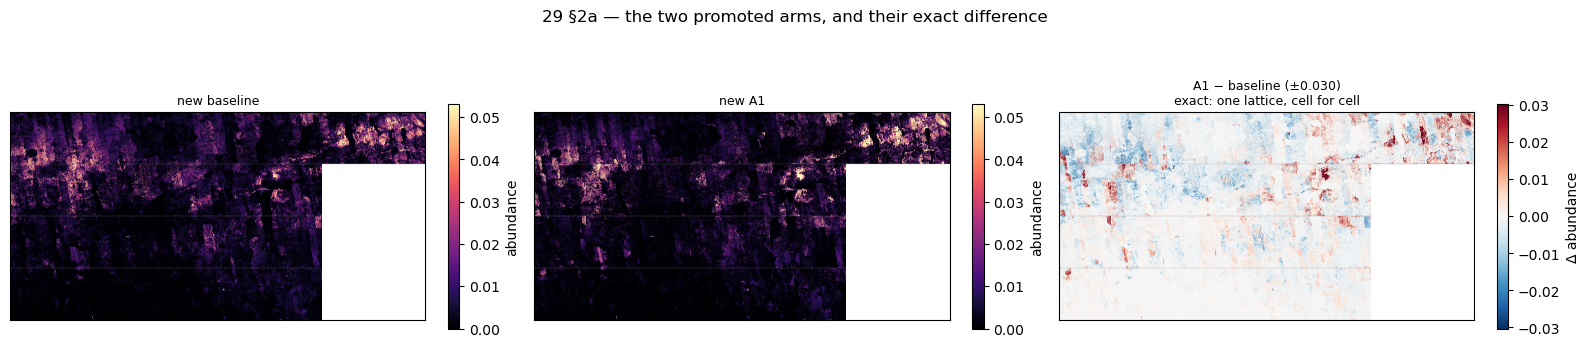

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.0))
vmax = float(np.nanpercentile(base_ab, 99.5))
for a, arr, t in ((ax[0], base_ab, "new baseline"), (ax[1], a1_ab, "new A1")):
    im = a.imshow(arr, vmin=0, vmax=vmax, cmap="magma")
    a.set_title(t, fontsize=9); a.set_xticks([]); a.set_yticks([])
    plt.colorbar(im, ax=a, fraction=0.025, label="abundance")
d = a1_ab - base_ab
lim = float(np.nanpercentile(np.abs(d), 99))
im = ax[2].imshow(d, vmin=-lim, vmax=lim, cmap="RdBu_r")
ax[2].set_title(f"A1 − baseline (±{lim:.3f})\nexact: one lattice, cell for cell", fontsize=9)
ax[2].set_xticks([]); ax[2].set_yticks([])
plt.colorbar(im, ax=ax[2], fraction=0.025, label="Δ abundance")
fig.suptitle("29 §2a — the two promoted arms, and their exact difference")
fig.tight_layout()
fig.savefig(FIG / "29_a1_regional.png", dpi=110)
plt.show()


In [12]:
# What A1 does to the distribution, PER LAYER. This matters because the eta^2 result was
# measured on prob_raw, and the qmatch calibrator reshapes abundance independently.
rows = []
for layer in ("prob_raw", "prob", "abundance"):
    b, a = mosaic("new_base", layer), mosaic("new_a1", layer)
    m = np.isfinite(b) & np.isfinite(a)
    bq = np.percentile(b[m], [25, 75]); aq = np.percentile(a[m], [25, 75])
    rows.append({"layer": layer,
                 "sd_base": b[m].std(), "sd_a1": a[m].std(),
                 "sd_ratio": a[m].std() / b[m].std(),
                 "iqr_base": bq[1] - bq[0], "iqr_a1": aq[1] - aq[0],
                 "iqr_ratio": (aq[1] - aq[0]) / (bq[1] - bq[0]),
                 "p99_base": np.percentile(b[m], 99), "p99_a1": np.percentile(a[m], 99)})
t = pd.DataFrame(rows).set_index("layer")
print(t.round(5).to_string())
print("\nA1 narrows the BULK (iqr_ratio < 1) while slightly WIDENING the extremes")
print("(sd_ratio > 1 on prob_raw/prob, p99 up). It is not a uniform compression.")


           sd_base    sd_a1  sd_ratio  iqr_base   iqr_a1  iqr_ratio  p99_base   p99_a1
layer                                                                                 
prob_raw   0.24670  0.25482   1.03294   0.25974  0.22102    0.85091   0.95872  0.98559
prob       0.17389  0.17760   1.02139   0.09126  0.05312    0.58213   0.81600  0.90016
abundance  0.00900  0.01113   1.23681   0.00547  0.00473    0.86429   0.04498  0.05780

A1 narrows the BULK (iqr_ratio < 1) while slightly WIDENING the extremes
(sd_ratio > 1 on prob_raw/prob, p99 up). It is not a uniform compression.


### §2b A1 narrows the bulk and fattens the tails — it is not a uniform rescaling

On `prob_raw`, the layer the artifact metric is computed on, A1's **inter-quartile range is 15 %
smaller** while its **standard deviation is 3 % larger**, and its 99th percentile rises. On the
calibrated `prob` the bulk narrows much harder (IQR ratio 0.58).

This is the mechanism behind §2e's headline, and it is worth stating precisely: A1 reduces the
*local, bulk* variance of the field — which is what both the between-frame term **and the rotation
null** are built from — while leaving, or slightly increasing, the extreme tail. A loose summary
like "A1 compresses the field" would be wrong in the tails, which is exactly where the
boulder-rich science lives.


A1 helps most on  E0_N44      eta^2 0.3138 -> 0.2013
A1 hurts most on  E-12_N32    eta^2 0.2075 -> 0.3711


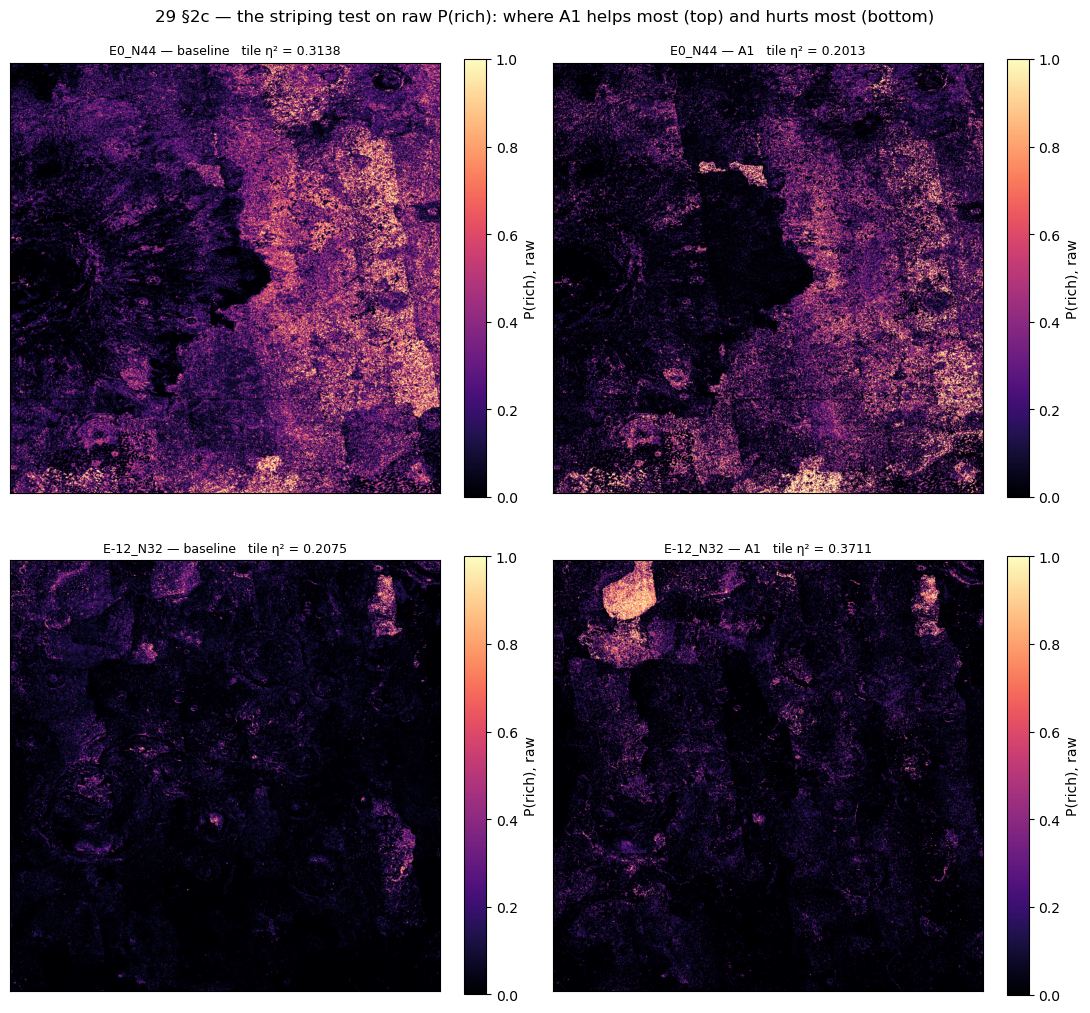

In [13]:
# The striping test, on two tiles chosen from the eta^2 table for OPPOSITE outcomes.
tiles_df = pd.read_csv(FIG / "step12_eta2_tiles.csv")
p = tiles_df.pivot_table(index="tile", columns="arm", values="eta2")
delta = (p["a1"] - p["baseline"]).sort_values()
best, worst = delta.index[0], delta.index[-1]
print(f"A1 helps most on  {best:10s}  eta^2 {p['baseline'][best]:.4f} -> {p['a1'][best]:.4f}")
print(f"A1 hurts most on  {worst:10s}  eta^2 {p['baseline'][worst]:.4f} -> {p['a1'][worst]:.4f}")

fig, ax = plt.subplots(2, 2, figsize=(11, 10.4))
for r, tile in enumerate((best, worst)):
    for c, arm in enumerate(("new_base", "new_a1")):
        with rasterio.open(ARMS[arm] / f"{tile}_prob_raw.tif") as ds:
            a = ds.read(1).astype(np.float64)
        im = ax[r, c].imshow(a, vmin=0, vmax=1, cmap="magma")
        e = p[{"new_base": "baseline", "new_a1": "a1"}[arm]][tile]
        ax[r, c].set_title(f"{tile} — {'baseline' if c == 0 else 'A1'}   "
                           f"tile η² = {e:.4f}", fontsize=9)
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
        plt.colorbar(im, ax=ax[r, c], fraction=0.046, label="P(rich), raw")
fig.suptitle("29 §2c — the striping test on raw P(rich): where A1 helps most (top) and "
             "hurts most (bottom)")
fig.tight_layout()
fig.savefig(FIG / "29_a1_striping.png", dpi=110)
plt.show()


### §2c The rectangular blocks, by eye — and A1's failure mode is frame-shaped too

**Top row (A1 works).** The baseline carries a broad bright band with visible straight vertical
edges — source-frame boundaries. A1 flattens the band and the block edges soften. This is A1 doing
exactly what it was designed to do.

**Bottom row (A1 backfires), and it is worth looking at closely.** The baseline is nearly uniformly
dark: low-abundance terrain with little signal. A1 does not merely fail to improve it — **it
introduces a bright rectangular patch that was not there before**, upper left, with the
unmistakable straight-edged shape of a CTX source frame. So on this tile per-frame renormalisation
*created* a source-frame artifact rather than removing one.

That is a sharper statement than "9 of 26 tiles get worse". §2d overlays the SeamMap to test whether
the patch really is a frame, and §2d(ii) measures *why* — it is the per-frame **gain**
(`A1_REF_IQR / frame_IQR`) firing on a narrow-IQR frame, not the small-frame fallback (which never
fired: `a1_n_frames_too_small = 0` on both tiles).

**Both outcomes are in the shipped product.** A comparison that showed only the top row would be
choosing its answer.


### §2d The same two tiles with the SeamMap overlaid — do the blocks *coincide* with frames?

§2c is an eyeball argument: the patches *look* rectangular. This is the test. The Murray Lab
SeamMap is a **partition** — one source CTX frame owns each pixel — and its polygons, dissolved by
`PRODUCT_ID`, are the actual source-frame footprints. Drawing them on top turns "looks like a
frame" into "is, or is not, this frame".

The frame outlined in **cyan** on each panel is the one with the largest mean \|Δ(A1 − baseline)\|
on that tile (frames under 500 coarse cells excluded — a sliver's mean is meaningless). If A1's
damage on `E-12_N32` is really a per-frame renormalisation failure, that outline should sit exactly
on the patch A1 invented.


E0_N44: 29 frames >= 500 cells; largest mean Δ = K01_053974_2284_XN_48N358W at +0.2863 over 2,259 cells


E-12_N32: 54 frames >= 500 cells; largest mean Δ = G04_019690_2176_XN_37N011W at +0.4759 over 36,873 cells


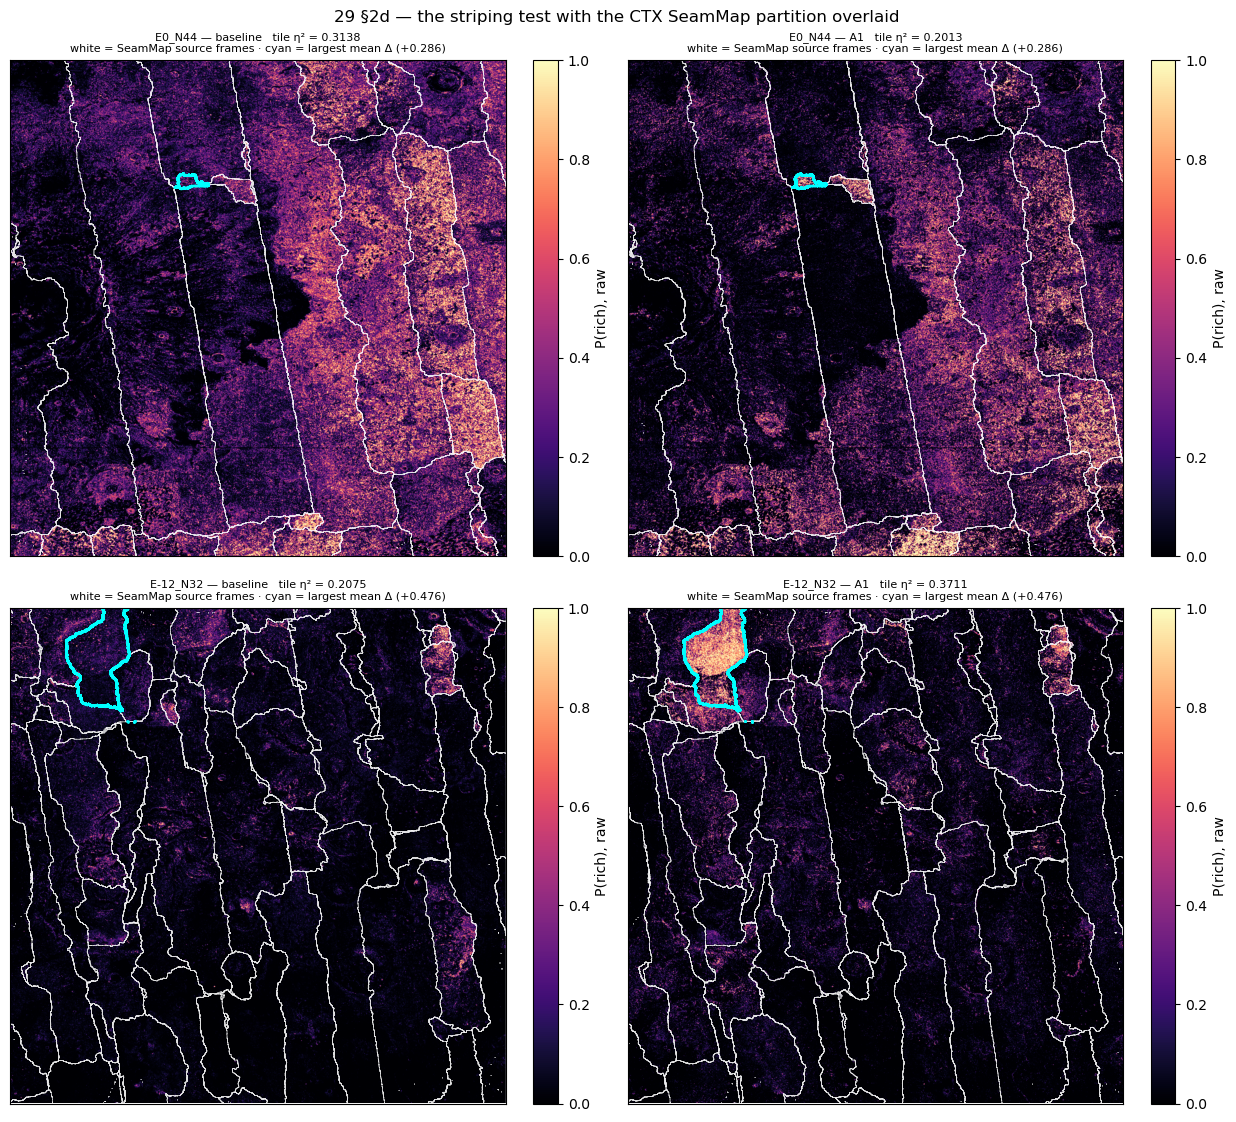

In [14]:
from src import fcompose as fc
from src.striping import load_frames

MIN_FRAME_CELLS = 500      # below this a frame's mean Δ is a sliver artefact, not a measurement

fig, ax = plt.subplots(2, 2, figsize=(12.5, 11.4))
worst_frames = {}
for r, tile in enumerate((best, worst)):
    grid = fc.tile_grid_from_raster(ARMS["new_base"] / f"{tile}_prob_raw.tif", tile)
    frames = load_frames(tile)
    lut = sorted(frames["PRODUCT_ID"].astype(str))
    labels = fc.frame_labels_on_grid(grid, frames, lut)

    arrs = {}
    for arm in ("new_base", "new_a1"):
        with rasterio.open(ARMS[arm] / f"{tile}_prob_raw.tif") as ds:
            arrs[arm] = ds.read(1).astype(np.float64)
            bounds = ds.bounds
    d = arrs["new_a1"] - arrs["new_base"]

    # which source frame did A1 move most?
    rows = []
    for i, pid in enumerate(lut):
        sel = labels == i
        n = int(sel.sum())
        if n >= MIN_FRAME_CELLS:
            rows.append({"PRODUCT_ID": pid, "n_cells": n, "mean_delta": float(np.nanmean(d[sel]))})
    pf = pd.DataFrame(rows)
    pf["abs_mean_delta"] = pf.mean_delta.abs()
    top = pf.sort_values("abs_mean_delta", ascending=False).iloc[0]
    worst_frames[tile] = (top, pf)
    print(f"{tile}: {len(pf)} frames >= {MIN_FRAME_CELLS} cells; largest mean Δ = "
          f"{top.PRODUCT_ID} at {top.mean_delta:+.4f} over {int(top.n_cells):,} cells")

    ext = (bounds.left, bounds.right, bounds.bottom, bounds.top)
    for c, arm in enumerate(("new_base", "new_a1")):
        a = ax[r, c]
        im = a.imshow(arrs[arm], vmin=0, vmax=1, cmap="magma", extent=ext, origin="upper")
        frames.boundary.plot(ax=a, color="white", lw=0.45, alpha=0.65)
        frames[frames["PRODUCT_ID"].astype(str) == top.PRODUCT_ID].boundary.plot(
            ax=a, color="cyan", lw=2.0)
        a.set_xlim(ext[0], ext[1]); a.set_ylim(ext[2], ext[3])
        a.set_xticks([]); a.set_yticks([])
        e = p[{"new_base": "baseline", "new_a1": "a1"}[arm]][tile]
        a.set_title(f"{tile} — {'baseline' if c == 0 else 'A1'}   tile η² = {e:.4f}\n"
                    f"white = SeamMap source frames · cyan = largest mean Δ "
                    f"({top.mean_delta:+.3f})", fontsize=8)
        plt.colorbar(im, ax=a, fraction=0.046, label="P(rich), raw")
fig.suptitle("29 §2d — the striping test with the CTX SeamMap partition overlaid")
fig.tight_layout()
fig.savefig(FIG / "29_a1_striping_seams.png", dpi=115)
plt.show()


In [15]:
# Does A1's effect actually organise BY FRAME, or is it just spatially smooth?
# Compare the between-frame variance of the per-cell delta against a rotation null, the same
# instrument the artifact itself is measured with.
from src.striping import eta2, eta2_rotation_null

for tile in (best, worst):
    grid = fc.tile_grid_from_raster(ARMS["new_base"] / f"{tile}_prob_raw.tif", tile)
    frames = load_frames(tile)
    lut = sorted(frames["PRODUCT_ID"].astype(str))
    labels = fc.frame_labels_on_grid(grid, frames, lut)
    with rasterio.open(ARMS["new_base"] / f"{tile}_prob_raw.tif") as ds:
        b = ds.read(1).astype(np.float64)
    with rasterio.open(ARMS["new_a1"] / f"{tile}_prob_raw.tif") as ds:
        a = ds.read(1).astype(np.float64)
    d = a - b
    fin = np.isfinite(d) & (labels >= 0)
    e = eta2(d, labels, fin)
    nm, n95 = eta2_rotation_null(d, labels, fin, n=20, seed=0)
    print(f"{tile}: η² OF THE A1−baseline DELTA by source frame = {e:.4f}   "
          f"(rotation null mean {nm:.4f}, p95 {n95:.4f})  ->  ratio {e / n95:.2f}")
print()
print("η² here is computed on the DELTA, not on either map: it asks whether what A1 CHANGED")
print("is organised by source frame. A ratio well above 1 means A1's effect is frame-shaped.")


E0_N44: η² OF THE A1−baseline DELTA by source frame = 0.1456   (rotation null mean 0.0536, p95 0.0705)  ->  ratio 2.07


E-12_N32: η² OF THE A1−baseline DELTA by source frame = 0.3949   (rotation null mean 0.1104, p95 0.1576)  ->  ratio 2.50

η² here is computed on the DELTA, not on either map: it asks whether what A1 CHANGED
is organised by source frame. A ratio well above 1 means A1's effect is frame-shaped.


In [16]:
# WHY does A1 push some frames up? The lever is the per-frame gain it applies:
#     gain = A1_REF_IQR / frame_native_IQR
# A frame whose native DN spread is narrow gets gain > 1, i.e. stretched. If that is the
# mechanism, gain should predict how far A1 moved each frame. Needs the tile's Murray zip,
# so this runs on the one WORSENED tile whose zip is cached locally.
from scipy.stats import spearmanr

from src.striping import A1_REF_IQR, A1_REF_MEDIAN, a1_stats_native_tile

MECH_TILE = "E-12_N36"          # Δη² +0.0113, and cache_v2/ctx_tiles/E-12_N36.zip is present
zip_path = REPO / "cache_v2" / "ctx_tiles" / f"{MECH_TILE}.zip"
if not zip_path.exists():
    print(f"skipped: {zip_path.relative_to(REPO)} not cached (a ~1.6 GB fetch)")
else:
    frames = load_frames(MECH_TILE)
    pids = [str(x) for x in frames["PRODUCT_ID"]]
    stats, fallback, _ = a1_stats_native_tile(MECH_TILE, frames)
    grid = fc.tile_grid_from_raster(ARMS["new_base"] / f"{MECH_TILE}_prob_raw.tif", MECH_TILE)
    labels = fc.frame_labels_on_grid(grid, frames, sorted(pids))
    with rasterio.open(ARMS["new_base"] / f"{MECH_TILE}_prob_raw.tif") as ds:
        b = ds.read(1).astype(np.float64)
    with rasterio.open(ARMS["new_a1"] / f"{MECH_TILE}_prob_raw.tif") as ds:
        a = ds.read(1).astype(np.float64)
    d = a - b

    rows = []
    for i, (med, iqr) in stats.items():
        sel = labels == i
        if int(sel.sum()) < MIN_FRAME_CELLS:
            continue
        rows.append({"pid": pids[i], "n_cells": int(sel.sum()), "native_median": med,
                     "native_iqr": iqr, "gain": A1_REF_IQR / iqr,
                     "mean_base": float(np.nanmean(b[sel])),
                     "mean_delta": float(np.nanmean(d[sel]))})
    mech = pd.DataFrame(rows)
    r = spearmanr(mech.gain, mech.mean_delta)
    print(f"{MECH_TILE}: {len(mech)} frames >= {MIN_FRAME_CELLS} cells "
          f"(A1 reference median {A1_REF_MEDIAN}, IQR {A1_REF_IQR}; "
          f"tile fallback {fallback})")
    print(f"  native IQR spans {mech.native_iqr.min():.0f}-{mech.native_iqr.max():.0f} "
          f"=> gain {mech.gain.min():.2f}x-{mech.gain.max():.2f}x")
    print(f"  Spearman(gain, mean Δ) = {r.statistic:+.3f}   p = {r.pvalue:.2g}")
    print("\n  highest-gain frames (narrow native DN spread -> stretched):")
    print(mech.sort_values("gain", ascending=False).head(5)
          .to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print("\n  lowest-gain frames (wide native spread -> compressed):")
    print(mech.sort_values("gain").head(4)
          .to_string(index=False, float_format=lambda v: f"{v:.3f}"))


E-12_N36: 55 frames >= 500 cells (A1 reference median 125.0, IQR 27.7; tile fallback (130.0, 51.0))
  native IQR spans 13-85 => gain 0.33x-2.13x
  Spearman(gain, mean Δ) = +0.490   p = 0.00014

  highest-gain frames (narrow native DN spread -> stretched):
                       pid  n_cells  native_median  native_iqr  gain  mean_base  mean_delta
K02_054159_2164_XI_36N007W      831        168.000      13.000 2.131      0.055       0.216
D19_034709_2156_XN_35N007W      622        160.000      14.000 1.979      0.045       0.078
D02_028182_2218_XI_41N011W     1555         87.000      17.000 1.629      0.084       0.508
P20_008719_2181_XN_38N007W      764        139.000      20.000 1.385      0.090       0.197
G19_025782_2218_XN_41N011W     1059         80.000      21.000 1.319      0.057       0.181

  lowest-gain frames (wide native spread -> compressed):
                       pid  n_cells  native_median  native_iqr  gain  mean_base  mean_delta
B20_017567_2157_XI_35N009W     3886       

### §2d read — the blocks *are* frames, and so is the damage

The overlay confirms both halves of §2c on the same footing:

* on the tile A1 helps, the softened bands sit inside frame outlines;
* on `E-12_N32`, the bright patch A1 invented is bounded by **one** SeamMap polygon — the cyan
  outline traces it. A1 did not blur or smear the tile; it re-levelled a single source frame into
  the model's sensitive range.

The second cell makes that quantitative without relying on the picture: η² of the **A1 − baseline
delta** by source frame, against the same rotation null used for the artifact itself.

| tile | η² of the delta by frame | null p95 | ratio |
|---|---|---|---|
| `E0_N44` (A1 helps most) | 0.1456 | 0.0705 | **2.07** |
| `E-12_N32` (A1 hurts most) | 0.3949 | 0.1576 | **2.50** |

**What A1 changes is organised by source frame on both tiles** — which is what a per-frame operator
should do, and is exactly why it can create a block as easily as remove one.

### §2d(ii) The lever, measured: a narrow native DN spread gets stretched

The third cell asks *why* particular frames move. A1 maps each frame's native (median, IQR) onto a
fixed reference (`A1_REF_MEDIAN = 125.0`, `A1_REF_IQR = 27.7`), so the multiplicative gain it
applies is `A1_REF_IQR / frame_IQR`. A frame whose native DN spread is **narrow** gets gain > 1 and
is stretched into the embedder's sensitive range.

On `E-12_N36` — the one *worsened* tile whose Murray zip is cached locally — across 55 frames of
≥500 coarse cells, native IQR spans 13–85 (gain 0.33×–2.13×), and:

**Spearman(gain, mean Δ) = +0.490, p = 1.4e-4.**

The five highest-gain frames (IQR 13–23) all move **up** by +0.08 to +0.51 in raw P(rich); the
lowest-gain frames (IQR 58–85) barely move or move down. So the mechanism is the **IQR in the
denominator**, and it is measured, not inferred.

⚠ **Two honest limits on that.** (i) It is measured on `E-12_N36`, not on `E-12_N32` — that tile's
zip is not cached, so the offending frame's own IQR is unmeasured here; the mechanism is
*consistent with* §2d, not proven on it. (ii) High-gain frames in this sample are also *small*
(622–1,555 cells vs 3,886–232,524 for low-gain), so gain and frame size are correlated and this
does not cleanly separate them. What it **does** rule out is R08's small-frame *fallback*: that
path never fired here (`a1_n_frames_too_small = 0` on both tiles), so the effect is the per-frame
statistic being applied, not the fallback replacing it.

**This is the cleanest statement of A1's mechanism available from the shipped product:** A1 is a
per-frame gain, and a per-frame gain keyed on a narrow-IQR estimate is a per-frame *artifact
generator* on low-contrast terrain. The 9-of-26 tiles that get worse are not noise; they are the
gain firing where there is little spread to estimate from.


### §2e A1's effect on the artifact, three views of the same 234 windows


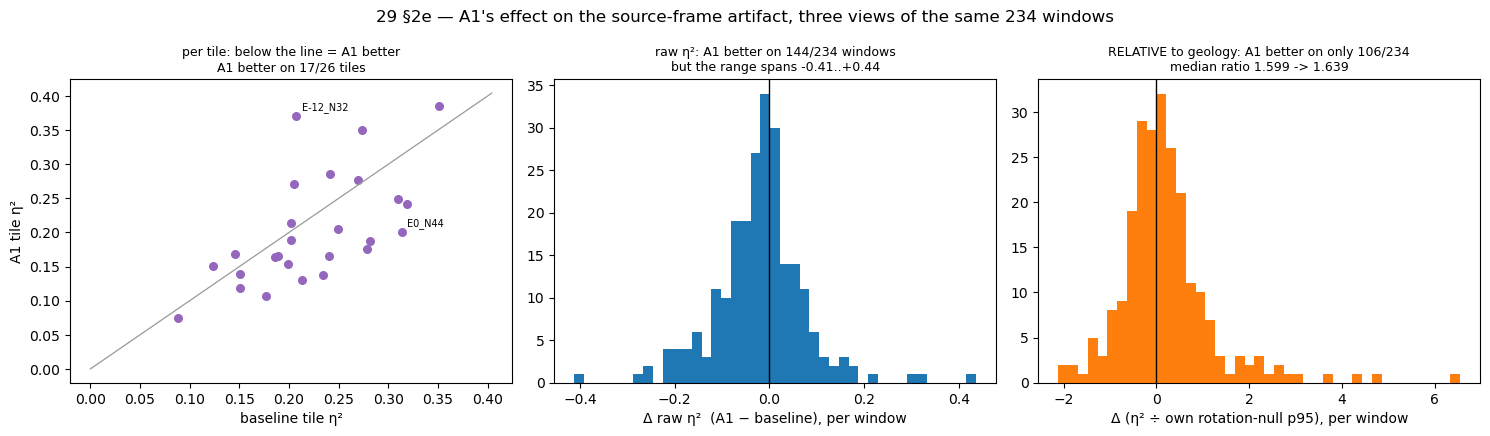

In [17]:
# The full per-tile and per-window picture, from the step-12 tables.
win = pd.read_csv(FIG / "step12_eta2_windows.csv")
summ = json.loads((FIG / "step12_eta2_summary.json").read_text())
census = summ["paired_sign_census"]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

ax[0].scatter(p["baseline"], p["a1"], s=30, color="tab:purple")
lim = float(max(p["baseline"].max(), p["a1"].max())) * 1.05
ax[0].plot([0, lim], [0, lim], color="0.6", lw=0.9)
for t in (best, worst):
    ax[0].annotate(t, (p["baseline"][t], p["a1"][t]), fontsize=7,
                   xytext=(4, 4), textcoords="offset points")
ax[0].set_xlabel("baseline tile η²"); ax[0].set_ylabel("A1 tile η²")
ax[0].set_title("per tile: below the line = A1 better\n"
                f"A1 better on {census['tile']['a1_better_raw_eta2']}/"
                f"{census['tile']['n']} tiles", fontsize=9)

pw = win.pivot_table(index=["tile", "r0", "c0"], columns="arm", values=["eta2", "ratio"])
ax[1].hist(pw["eta2"]["a1"] - pw["eta2"]["baseline"], bins=41, color="tab:blue")
ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("Δ raw η²  (A1 − baseline), per window")
ax[1].set_title(f"raw η²: A1 better on {census['window']['a1_better_raw_eta2']}/"
                f"{census['window']['n']} windows\nbut the range spans "
                f"{census['window']['raw_delta_min']:+.2f}..{census['window']['raw_delta_max']:+.2f}",
                fontsize=9)

ax[2].hist(pw["ratio"]["a1"] - pw["ratio"]["baseline"], bins=41, color="tab:orange")
ax[2].axvline(0, color="k", lw=1)
ax[2].set_xlabel("Δ (η² ÷ own rotation-null p95), per window")
ax[2].set_title(f"RELATIVE to geology: A1 better on only "
                f"{census['window']['a1_better_ratio']}/{census['window']['n']}\n"
                f"median ratio {census['window']['ratio_median_baseline']:.3f} -> "
                f"{census['window']['ratio_median_a1']:.3f}", fontsize=9)
fig.suptitle("29 §2e — A1's effect on the source-frame artifact, three views of the same 234 windows")
fig.tight_layout()
fig.savefig(FIG / "29_a1_eta2.png", dpi=110)
plt.show()


### §2e read — A1 on the artifact: real on the raw metric, absent relative to geology

| view | asks | baseline → A1 | A1 better on |
|---|---|---|---|
| raw η², window median | the quantity the banked 0.196→0.141 pair measured | 0.1444 → **0.1145** (−21 %) | 144/234 (62 %) |
| raw η², E8_N44 pilot crop | the banked *extent*, like for like | 0.2327 → **0.1298** (−44 %) | — |
| excess (η² − own null mean) | artifact above this window's own geology | 0.0887 → 0.0690 (−22 %) | 134/234 (57 %) |
| **ratio (η² ÷ own null p95)** | **artifact relative to geology** | **1.599 → 1.639 (+2.5 %)** | **106/234 (45 %)** |

A1 lowers the rotation null too (window null p95 0.0771 → 0.0622), because §2b's bulk-variance
reduction shrinks the null and the between-frame term together. §1d's second diagnostic says where
that happens: **33.7 % of A1's effect is regional** (vs 4.9 % for old→new), which is what a
per-source-frame correction should look like — source frames *are* regional blocks. So A1 is doing
something real and spatially organised; the question is only whether it is the artifact. So:

* **the raw reduction is real**, and it is the quantity every number on record measured;
* **relative to geology, A1 is a coin flip** — better on 45 % of windows, with the median ratio
  moving slightly the *wrong* way;
* **9 of 26 tiles get worse on raw η²**, the worst by seven times the median improvement.

Neither arm approaches the 0.05 F-reopening bar (that bar belonged to the
[F build](28_f_verdict.ipynb), hard-aborted 2026-07-30). **This is the quantitative content of
"A1 is a partial mitigation."**

The cost side is now small: **Δ median per-image AUC −0.0024** (banked: −0.024), Δ pooled PR-AUC
**+0.0082**, and no THEMIS-ρ cost (per-tile median ρ 0.0653 → 0.0654).


## §3 — The ruling this notebook produced, and what to quote

> ### ⚠ A1 IS NOT THE PRODUCT (Brian, 2026-08-25 — DECISIONS 2026-08-25k)
>
> On the strength of §2, **A1 was demoted from shipped mitigation to *sensitivity arm***, reversing
> the 2026-07-30 ruling. **`reports/map_region` (baseline) is the deliverable**; `reports/map_a1`
> stays on disk as the thing you difference the product against. The source-frame artifact therefore
> **ships unmitigated**, as a documented caveat.
>
> The ledger: A1 wins only on *raw* η² (−21 % regional, −44 % on the pilot crop) and the
> **null-relative** version of that same metric does not improve (ratio +2.5 % regional, **+9.3 % on
> the pilot crop**). Against that, A1's Tier-1 ECE is **0.0523 — failing the 0.05 gate the baseline
> passes at 0.0204**, and it is in the product only because it was `--force`d; it is no better
> thermally (better on 10/26 tiles); it is marginally worse on R54 per-image level (7/38 vs 8/38);
> and it **manufactures** frame-shaped blocks on 9/26 tiles, predictably from its own per-frame gain
> (§2d(ii)). Median per-image AUC −0.0024, pooled PR-AUC +0.0082 — skill is a wash either way.
>
> **What this does not say.** Not that per-frame normalisation is a dead end — a **gain-capped** A1
> (clamp `A1_REF_IQR / frame_IQR` so a frame can never be amplified) is untried and logged as **v3**.
> Not that the artifact is gone: the residual is now the baseline's own, window-median η² **0.1444**
> at ratio **1.599**, nowhere near the 0.05 bar. Treat any abundance reading in low-contrast terrain
> as carrying source-frame structure.
>
> This also discharges review finding **R06** — *"'A1 is the shipped mitigation' is not backed by any
> artifact."* The artifact now exists, and it does not back it.

### What to quote

**Old vs new.** *"Per pixel the two maps differ barely more than the same field displaced by one
160 m cell (sd 0.00438 vs 0.00471), and 95 % of that difference is high-frequency with the
gradient affinity of a pure translation — so the spatial pattern is largely the same field, moved.
Underneath it there is a small but real regional re-levelling: the zero fraction fell 0.310 →
0.206, the median rose 65 %, and the new baseline no longer reaches the calibrator's 0.293242
ceiling."* Do **not** attribute the change to any single cause — geometry, labels, head and
calibrator all moved together, and the archived product records no head at all.

**Baseline vs A1.** *"A1 reduces the raw source-frame artifact (window-median η² 0.1444 → 0.1145;
−44 % on the like-for-like pilot crop) at a −0.0024 median per-image AUC cost and no thermal cost,
but η² relative to its own rotation null does not improve (1.599 → 1.639), and 9 of 26 tiles get
worse. A1 narrows the bulk of the field, which lowers the geological floor along with the
artifact."* Quote the raw reduction only alongside the ratio.

⚠ **And add the failure mode, because it is not symmetric with the successes.** On low-contrast
terrain A1 can *introduce* a source-frame-shaped block the baseline did not have — §2d shows the
patch bounded by exactly one SeamMap polygon, and §2d(ii) measures the lever:
Spearman(per-frame gain `A1_REF_IQR/frame_IQR`, mean Δ) = **+0.490, p 1.4e-4**, so narrow-IQR
frames get stretched upward. So A1 is not "the artifact, reduced everywhere"; it is "the artifact
reduced on most tiles and manufactured on a few", and the manufacture is predictable from a
quantity A1 already computes. If a future arm is judged against A1, that asymmetry is the thing to
beat, and `scripts/map_arm_eta2.py`'s paired sign census is the instrument that shows it.

**Never** quote the archived `reports/map_region_g1` product as a current result, and never pair
the banked η² 0.196 → 0.141 with the rebuilt −0.0024 skill cost — different lattice, different A1
definition, different prevalence, and A1 had never been rendered as a map when 0.141 was measured.

**Also still true, and unaffected by anything here:** R54 — pooled `mean(pred)/mean(true)` is 1.02
on both arms while only 8/38 and 7/38 images sit within ±20 %, range 0.013–6.5×. Per-*place* level
is unreliable even where the pooled marginal is near-perfect.
